# Tutorial on NV centers
The goal of this tutorial is to present the physics of NV centers. We will see how they can be used for magnetometry, and see how they provide a great platform to manipulate spins at room temperature. 

## 1) Short introduction to `qutip`

In [7]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.optimize import curve_fit

# Plot settings
# plt.rcParams["font.family"] = "Cambria"
# plt.rcParams['mathtext.fontset'] = 'custom'
# plt.rcParams['mathtext.rm'] = 'Cambria'
# plt.rcParams['mathtext.it'] = 'Cambria:italic'
# plt.rcParams['mathtext.bf'] = 'Cambria:bold'
plt.rcParams["font.size"] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16

`qutip` is very useful to work with quantum states and operators on python.

Let's consider a two-level system (TLS) with an excited state $\ket{e}$ and a ground state $\ket{g}$, forming a basis $\{\ket{e}, \ket{g}\}$ of a dimension 2 Hilbert space. 

 **1.1) Build the basis as qutip objects**

In [9]:
# Build the basis states
e_ket = qt.basis(2, 0) # excited state
g_ket = qt.basis(2, 1) # ground state
display(g_ket) # ground state ket
display(e_ket * e_ket.dag()) # projector onto the excited state

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]

**1.2) Build the lowering and raising operators $\sigma_- = \ket{g}\bra{e}$ and $\sigma_+ = \ket{e}\bra{g}$**

**1.3) Build the Pauli matrices $\sigma_z = \sigma_+ \sigma_- - \sigma_- \sigma_+$ ; $\sigma_x = \sigma_+ + \sigma_-$ ; $\sigma_y = i (\sigma_- - \sigma_+)$**

**NB: You can also use the built-in functions `qt.spin_Jx(1/2)` or `qt.sigmax()` to build $\sigma_x$ (same for $\sigma_y, \sigma_z, \sigma_+, \sigma_-$). Just be careful with the convention that you choose for your basis (either $(\ket{e}, \ket{g})$ or $(\ket{g}, \ket{e})$).**

In [10]:
sigm = g_ket * e_ket.dag()
sigp = e_ket * g_ket.dag() 

sigz = sigp * sigm - sigm * sigp
sigy = 1j * (sigm - sigp)
sigx = sigp + sigm

# Check the Pauli algebra
print(qt.commutator(sigx, sigy) == 2j*sigz, qt.commutator(sigy, sigz) == 2j*sigx, qt.commutator(sigz, sigx) == 2j*sigy)


True True True


Consider the following Hamiltonian:
$$H = \hbar \begin{pmatrix}
\Delta  & \Omega \\
\Omega & - \Delta 
\end{pmatrix}$$

**1.4) Build it in qutip and compute (numerically) its eigenvalues and eigenstates. We will take $\hbar=1$ and $\Omega=1$. Plot the eigenenergies of $H(\Delta)$ for $\Delta$ between $-5$ and $5$** 

In [1]:
HBAR = 1
OMEGA = 1

<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_725965/2514390185.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Detuning ($\Delta$)')
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
find

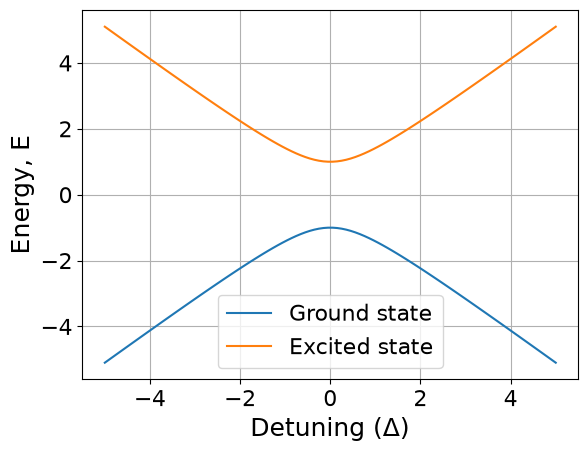

In [16]:
# after building an object H, you can use H? to access the documentation and available methods
DELTAS = np.linspace(-5, 5, 100)


eigenenergies = []

for delta in DELTAS:
    H = HBAR * (sigz * delta + sigx * OMEGA)
    eigenv = H.eigenenergies()
    eigenenergies.append(eigenv)

eigenE = np.array(eigenenergies)

plt.plot(DELTAS, eigenE[:, 0], label='Ground state')
plt.plot(DELTAS, eigenE[:, 1], label='Excited state')
plt.xlabel('Detuning ($\Delta$)')
plt.ylabel('Energy, E')
plt.legend()
plt.grid()
plt.show()

In [7]:
H?

Object `H` not found.


**Bonus**

**1.5) Use `qt.mesolve` to solve the evolution of the TLS under this Hamiltonian, with $\Delta = 0.4$. Take $\ket{e}$ as the initial state, and solve for $t$ between $0$ and $10$**

**1.6) Plot the expectation value of $\sigma_z$ and $\sigma_y$ as a function of time**

In [ ]:
DELTA = 0.4
H = HBAR * (sigz * DELTA + sigx * OMEGA)
T_LIST = np.linspace(0, 10, 1000)

obs = [sigz, sigy]

evol = qt.mesolve(H, e_ket, T_LIST, e_ops = obs)

sigmazT = evol.expect[0]
sigmayT = evol.expect[1]

plt.plot(T_LIST, sigmazT, label="<$\sigma_z(T)$>")
plt.plot(T_LIST, sigmayT, label="<$\sigma_y(T)$>")
plt.xlabel('Time (T)')
plt.ylabel('Exp. Val.')
plt.legend()
plt.grid()
plt.show()

## 2) NV centers

NV centers are point-like defects in a diamond lattice : two carbon atoms are replaced by a nitrogen atom, a vacancy and an additionnal electron. They are fluorescent: they emit red light ($\lambda \approx 637nm$) when excited by a green laser ($532 nm$). In the electronic ground state, we obtain a **spin 1** fine structure. Under a continuous green laser excitation, NV centers are polarized in the $\ket{m_s = 0}$ state (even at room temperature), and the state $\ket{m_s = 0}$ is optically brighter than states $\ket{m_s = \pm 1}$, which provides a way to optically measure the spin state.

Fine structure Hamiltonian in the electronic ground state:
$$ \hat{H}_f = \hbar \mathcal{D}_{gs} (\hat{\vec{S}}.\vec{u}_{NV})^2 + \hbar \gamma_e \hat{\vec{S}}.\vec{B} $$

where $\hat{S}_{x,y,z}$ are dimensionless spin 1 operators such that $[S_k, S_l] = \epsilon_{klm} i S_m$.

Here, $\vec{u}_{NV}$ is the N-V axis, which defines a preferential quantization axis.

**2.1) Build the $\hat{S}_{x,y,z}$ operators (using `qutip` built-in functions)**

**2.2) Build a function that returns H for any given magnetic field $\vec{B}$ and any direction $\vec{u}_{NV}$** 

In [2]:
# Define constants
D = 2870 # MHz
gamma_e = 2.8 # MHz/G

In [ ]:
# 2.1
Sx = qt.spin_Jx(1)
Sy = qt.spin_Jy(1)
Sz = qt.spin_Jz(1)

def H(B, u):
    return D * (Sx * u[0] + Sy * u[1] + Sz * u[2])**2 + gamma_e * (Sx * B[0] + Sy * B[1] + Sz * B[2])


**2.3) Set $\vec{u}_{NV} = \vec{u}_z$. Consider $\vec{B} = B_1 \vec{u}_z$ and plot the eigenenergies of the system for $B_1$ between $0$ and $1100G$. Do the same for $\vec{B} = B_1 \vec{u}_x$ and $\vec{B} = B_0 \vec{u}_z + B_1 \vec{u}_x$, with $B_0 = 100G$.**

**2.4) What component of $\vec{B}$ has the dominant effect?** 

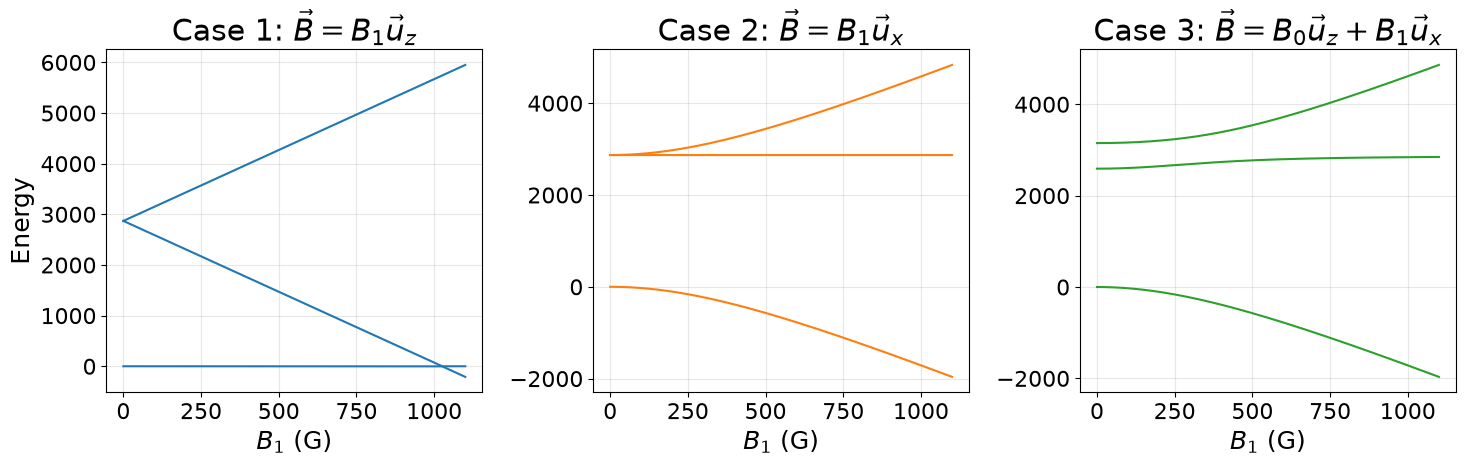

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

B0 = 100
B1 = np.linspace(0, 1100, 10000)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for case_idx in range(1, 4):
    energies_for_case = []
    
    for b_val in B1:
        if case_idx == 1:
            B_vec = np.array([0, 0, b_val])
            title = r"Case 1: $\vec{B} = B_1 \vec{u}_z$"
        elif case_idx == 2:
            B_vec = np.array([b_val, 0, 0])
            title = r"Case 2: $\vec{B} = B_1 \vec{u}_x$"
        elif case_idx == 3:
            B_vec = np.array([b_val, 0, B0])
            title = r"Case 3: $\vec{B} = B_0 \vec{u}_z + B_1 \vec{u}_x$"
            
        evals = H(B_vec, u).eigenenergies()
        energies_for_case.append(evals)
        
    energies_for_case = np.array(energies_for_case) 
    
    ax = axes[case_idx - 1]
    color = f"C{case_idx-1}" 
    
    # Loop through all energy levels (column of energies_for_case)
    for level_idx in range(energies_for_case.shape[1]):
        ax.plot(B1, energies_for_case[:, level_idx], color=color)
    
    ax.set_title(title)
    ax.set_xlabel("$B_1$ (G)")
    ax.grid(True, alpha=0.3)
    
    if case_idx == 1:
        ax.set_ylabel("Energy")

plt.tight_layout()
plt.show()

We observe that the dominant component of the magnetic field is the one which is aligned with the NV axis (Case 1): to first order, for small values of $B$, the excited energy level start to clearly separate, while the other cases this separation is less pronunciated. Things change when going to higher values of $B$, for which second order effects of the transverse field appear as a deviation of the ground state to lower values.

### NV centers as magnetic field sensors

#### First experiment 
We will now look at experimental data obtained on a dense ensemble of NV centers ($\sim 10$ ppm). The sample is continuously exposed to a green laser. A microwave antenna is placed close to the sample, and we do a frequency scan of the microwave (from 2 to 4 GHz for example). For each value of f, we measure the fluorescent light. This is often called "Optically Detected Magnetic Resonance" (ODMR).

In a diamond lattice, there are 4 possible orientations for N-V axes. In an ensemble of NV centers, each possible direction corresponds to a class of NV centers (A,B,C,D). For a given ODMR signal, we will name the NV classes according to the projection of the magnetic field on the NV axis. Class A corresponds to the highest value and class D to the lowest value. 

**2.5) Let's now plot the ODMR signal from experimental data files `data_01.txt` and `data_02.txt`. Why do we see dips in the intensity of the fluorescent light?**

**2.6) What can you say about the orientation of the magnetic field relative to the NV axes in these experiments? (qualitatively)** 

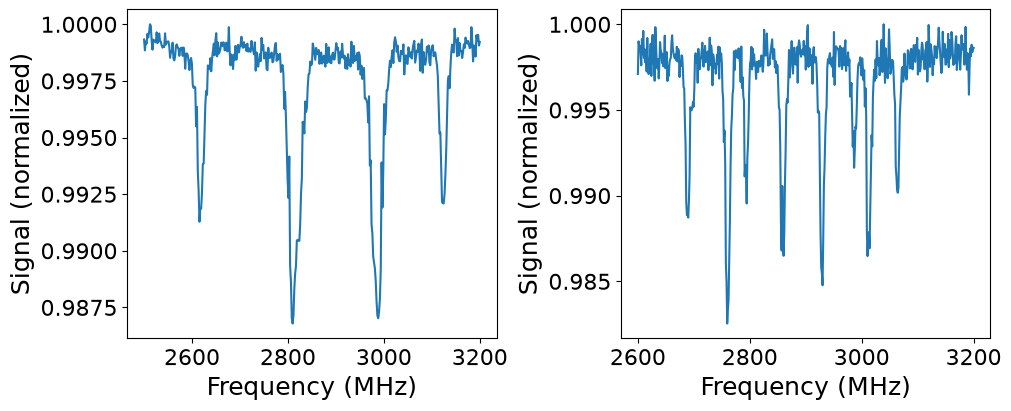

In [27]:
data1 = np.loadtxt("NV_data/data_01.txt")
freqs1, signal1 = data1[:,0], data1[:,1] # The signal is the intensity of the fluorescent light, normalized to its maximum value

data2 = np.loadtxt("NV_data/data_02.txt")
freqs2, signal2 = data2[:,0], data2[:,1]

fig = plt.figure(figsize=(10,4), layout="constrained")
ax = fig.add_subplot(121)
ax.plot(freqs1, signal1)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (normalized)")

ax= fig.add_subplot(122)
ax.plot(freqs2, signal2)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (normalized)")

plt.show()

* We see dips in the signal because, as we sweep in the frequency range with our antenna, the energy we inject to the diamond (NV center) equals exactly the energy gap between the GS and the 1st excited state, making the NV center transition to a state which is less luminous (this is why we observe the dip in the fluorescent light).
* We might have many NV centers in a diamond. A single NV center might be in 4 different (axial) directions (see diagramatic structure). If we consider an average of all the possible directions all the NV centers can take, we are left with 4 NV axes. If the magnetic field is applied to a random direction (which does not align with any NV axis), then we observe 8 peaks in total: 2 peaks for each direction. 
* The reason why we observe 2 peaks for each NV axis is because (see Fig. of Case 1 above) for a given non-zero value of $B$, as we sweep the signal (and increase the energy, making an energy sweep), we cut exactly two times the splitted energy levels.

**2.7) Estimate the magnetic field applied to the sample in the `data_01` measurement. Check consistency by computing the eigenvalues of the Hamiltonian for the different classes, given this magnetic field.**

Let us consider the easy case: when the magnetic field is parallel to one axis of the NV center (left panel):
$$ \vec{B} = B_0 \hat u_z, \qquad \hat u_{NV} = \hat u_{z}, $$
such that the Hamiltonian is
$$ H = \hbar D S_z^2 + \hbar \gamma_e B_z S_z$$
whose eigenstates are $\ket{0}, \ket{+1}, \ket{-1}$, and therefore the energies are
$$ E = 0, \hbar D \pm \hbar \gamma_e B_z. $$

We observe that there can be two transitions from the GS $\ket{0}$ to the eigenstates $\ket{\pm 1}$, which correspond to the two peaks we observe in the the signal from our frequency sweep (per axis). If we look at the two smallest peaks of the left panel (corresponding to the ones of the aligned NV axis to $B$), we can compute the magnetic field from the frequency:
$$ E_1 = \hbar D - \hbar \gamma_e B_z  $$
$$ E_2 = \hbar D + \hbar \gamma_e B_z  $$
$$ \Rightarrow \Delta E = E_2 - E_1 = 2 \hbar \gamma_e B_z $$

In [5]:
dE = HBAR * (3124.75 - 2615.5)
Bz = dE / (2 * HBAR * gamma_e)
print("Bz = ", Bz, " G.")

Bz =  90.9375  G.


**2.8) Bonus question : Find a magnetic field vector that fits the `data_02.txt` dataset.**

In [19]:
# You can use the following convention for the 4 N-V axes:
n1 = np.array([1, 1, 1])/np.sqrt(3)
n2 = np.array([1, -1, -1])/np.sqrt(3)
n3 = np.array([-1, 1, -1])/np.sqrt(3)
n4 = np.array([-1, -1, 1])/np.sqrt(3)

n_array = np.array([n1,n2,n3,n4])

In [20]:
# f1 = 
# f2 = 
# f3 = 
# f4 = 
# f5 = 
# f6 = 
# f7 = 
# f8 = 


*Note that it is impossible to fully determine the magnetic field vector from an ODMR measurement alone. For example, we can't differentiate between $\vec{B}$ and $- \vec{B}$.*

### NV centers as controllable spins

Thanks to the cristalline structure of diamond, NV center spins are quite well isolated from the environment (for a solid state system). This allows for coherent control of the electronic spin, even at room temperature. Let's consider an effective two level-system, for example formed by the pair ($\ket{m_s = 0}$, $\ket{m_s = +1}$). We need to take into account decoherence, which leads to the introduction of two characteristic durations $T_1$ and $T_2$, that answer two distinct questions:

- $T_1$ is the characteristic relaxation time: if I put my spin in $\ket{m_s = +1}$, how long does it take for it to go back to $\ket{m_s = 0}$? 
- $T_2$ is the characteristic coherence time: if I put my spin in a coherent superposition of $\ket{m_s = 0}$ and $\ket{m_s = +1}$, for how long is the phase of the superposition preserved?

We also need to introduce the effective coherence time $T_2^*$. Indeed, our sample is subject to magnetic field inhomogeneities, which cause a fast decoherence between different electronic spins. However, performing a bit-flip (or $\pi$-pulse) on the sample reverses the effect of these stable inhomogeneities. This gives us access to the "true" coherence time $T_2$.

#### 2nd experiment
Experimental protocol: we place our sample in a magnetic field, aligned with one NV axis (see `data_01`) to have well defined spin states. The sample is polarized in $\ket{m_s = 0}$ by a long green laser pulse. The laser is turned off and a microwave pulse of duration $t$ is sent on the sample. The microwave frequency is chosen to fit the transition $\ket{m_s = 0}$ → $\ket{m_s = +1}$ of class A. A short laser pulse is then sent to measure the fluorescence of the sample. We repeat this and scan the value of $t$. 


**2.9) Plot the experimental data from `data_03.txt`. What do you see?**

Text(0, 0.5, 'Signal (normalized)')

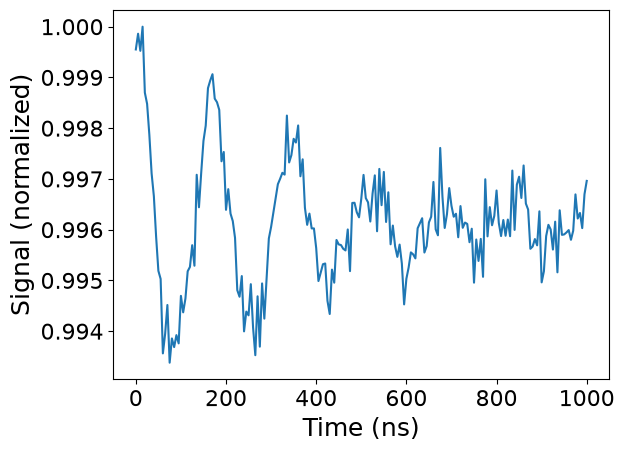

In [15]:
data3 = np.loadtxt("NV_data/data_03.txt")
t3, s3 = data3[:,0], data3[:,1] # time in ns, signal normalized to its maximum value

plt.plot(t3, s3, label="Exp. Data")
plt.xlabel("Time (ns)")
plt.ylabel("Signal (normalized)")

I observe oscillations (Rabi) along time, corresponding to the state of the spin going from the GS to the excited state and back, effectively rotating in the Bloch sphere. In a perfect world, we would observe oscillations with the same amplitude along time. However, in the real world we have decoherence of the state, which damps exponentially the amplitude of the oscillation signal along time as $e^{-t / T^{*}_2}$, dictated by the effective decoherence time.

**2.10) Estimate the length of a $\pi$-pulse in these experimental conditions.**


At $T=0$, we are in the GS $\ket{0}$. As the signal goes down, a rotation is being applied. The first dip corresponds to the $\pi-$ pulse because the state has been rotated to state $\ket{-1}$ in $T_1 = 60$ ns. At $T=30$ ns, the state is rotated only half a $\pi-$ pulse, so the state is in the pure superposition $\ket{\Psi} = \ket{0} + \ket{1}$.

#### 3rd experiment

We now consider another experimental protocol. A long laser pulse in applied on the sample. A $\pi$-pulse and a $\pi/2$-pulse (microwave) are applied to the sample. We wait a time $\Delta t$. A second $\pi/2$-pulse is applied, and we measure the fluorescence with a short laser pulse. We repeat for different values of $\Delta t$. 

**2.11) Plot the experimental data. What quantity can we extract from it?**

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_4714/3795971211.py:6: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta$t (ns)")


Text(0, 0.5, 'Signal (photons/s)')

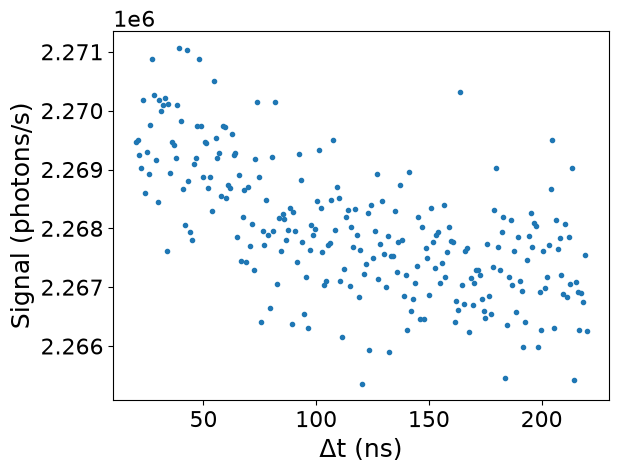

In [20]:
data4 = np.loadtxt("NV_data/data_04.txt")
t4 = data4[:,0] # delta t in ns
s4 = data4[:,1] # signal in photons/s

plt.plot(t4, s4, ".", label="Exp. Data")
plt.xlabel("$\Delta$t (ns)")
plt.ylabel("Signal (photons/s)")

**2.12) Fit the experimental data to estimate said quantity.**

T2* = 68 +/- 15 ns


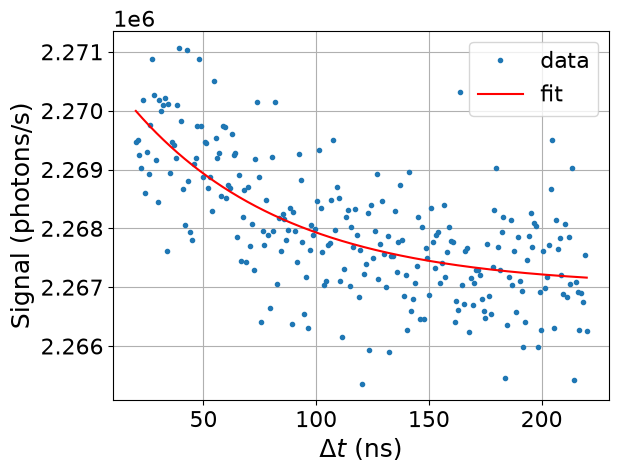

In [ ]:
def decay(t, offset, A, T2star):
    return offset + A * np.exp(-t / T2star)

p0 = [s4.min(), s4[0] - s4.min(), 100]  # init guesses for offset, A, T2star
popt, pcov = curve_fit(decay, t4, s4, p0=p0)
perr = np.sqrt(np.diag(pcov))

offset_fit, A_fit, T2star_fit = popt
print(f"T2* = {T2star_fit:.0f} +/- {perr[2]:.0f} ns")

t_fine = np.linspace(t4.min(), t4.max(), 2000)
plt.plot(t4, s4, '.', label="data")
plt.plot(t_fine, decay(t_fine, *popt), 'r-', label="fit")
plt.xlabel(r"$\Delta t$ (ns)")
plt.ylabel("Signal (photons/s)")
plt.legend()
plt.grid()
plt.show()

The fit of the experimental data allows us to extract the effective decoherence time, $T^{*}_2$. The next experiment introduces a $\pi-$ pulse in the middle of the two $\pi-$ half pulses to remove some of the inhomogeneities of the magnetic field (but there are still other sources of decoherence, of course).

### 4th experiment

We will now look at a spin-echo measurement. After a long laser pulse, we send a $\pi/2$ pulse on the sample. After a duration $\Delta t/2$, we send a $\pi$-pulse. After another $\Delta t /2$, we send a $\pi/2$-pulse and measure the fluorescence with a short laser pulse. The intermediate $\pi$ pulse removes the decoherence caused by static inhomogeneities of the magnetic field. 

**2.13) Plot the experimental data. What quantity can we extract from this measurement?**

**2.14) Fit the experimental data to estimate said quantity.**

With the $\pi-$ pulse, we effectively remove the static inhomogeneities of the magnetic field, allowing us to access the true decoherence time $T_2$!

T2 = 189 +/- 20 ns


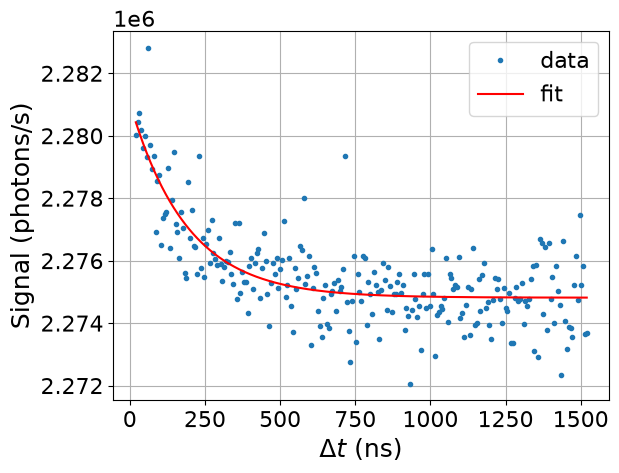

In [24]:
data5 = np.loadtxt("NV_data/data_05.txt")
t5, s5 = data5.T

def decay(t, offset, A, T2):
    return offset + A * np.exp(-t / T2)

p0 = [s5.min(), s5[0] - s5.min(), 100]  # init guesses for offset, A, T2
popt, pcov = curve_fit(decay, t5, s5, p0=p0)
perr = np.sqrt(np.diag(pcov))

offset_fit, A_fit, T2_fit = popt
print(f"T2 = {T2_fit:.0f} +/- {perr[2]:.0f} ns")

t_fine = np.linspace(t5.min(), t5.max(), 2000)
plt.plot(t5, s5, ".", label="data")
plt.plot(t_fine, decay(t_fine, *popt), 'r-', label="fit")
plt.xlabel(r"$\Delta t$ (ns)")
plt.ylabel("Signal (photons/s)")
plt.legend()
plt.grid()
plt.show()

### 3) Hyperfine structure of the NV center
$^{14}N$ atoms have a nuclear spin of $1$ that couples to the electronic spin. This adds a hyperfine structure on top of the already described fine structure. Assuming a magnetic field along the N-V ($z$) axis, we obtain the following (approximate) Hamiltonian:
$$ \hat{H} = \hat{H}_f + \hat{H}_{hf}$$
$$ \hat{H}_{hf} = - \hbar \mathcal{Q}_N \hat{I}_z^2 - \hbar \gamma_N B \hat{I}_z - \hbar \mathcal{A}_{zz} \hat{I}_z \hat{S}_z$$
Where $\hat{I}_z$ is a nuclear spin operator. We give $\gamma_N = 0.31$ kHz/G. $\mathcal{A}_{zz}$ and $\mathcal{Q}_N$ are in the MHz range. 

**3.1) Why didn't we observe this hyperfine structure in previous experimental data?**

The peaks due to the hyperfine structure are too thin to be resolved in the range of frequencies we were working before (where the fine structure effects were very broad in frequency compared to the peaks we observe below).

---

`data_06` is ODMR experimental data from a much purer diamond sample. It corresponds to the transition $\ket{m_s=0, m_I}$ to $\ket{m_s=-1, m_I}$.

**3.2) What do you notice?**

Text(0, 0.5, 'Signal (normalized)')

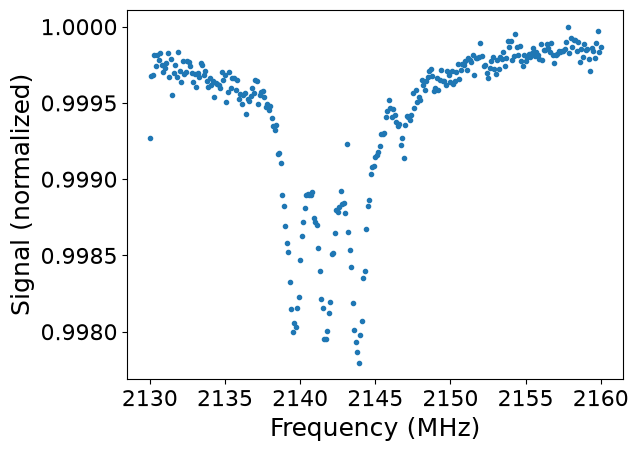

In [31]:
data6 = np.loadtxt("NV_data/data_06.txt")
freqs6 = data6[:,0]
s6 = data6[:,1]

plt.plot(freqs6, s6, ".", label="data")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Signal (normalized)")

For a magnetic field of around $500$ G, the nuclear spin is slightly polarized in the state $\ket{m_I = +1}$ by the green laser driving, and the state $\ket{m_s=0, m_I=+1}$ is brighter than the others. This allows us to perform a direct measurement of the nuclear spin transitions, by ODNMR (the N stands for nuclear). We use the same protocol for ODMR and ODNMR, except that we excite the sample with radio waves.

**3.3) Plot the ODNMR signal from `data_07.txt`. Identify the nuclear transitions and estimate the values of $B$, $\mathcal{A}_{zz}$ and $\mathcal{Q}_N$. We assume $\mathcal{Q}_N > \mathcal{A}_{zz} + \gamma_N B$.**

Text(0, 0.5, 'Signal (normalized)')

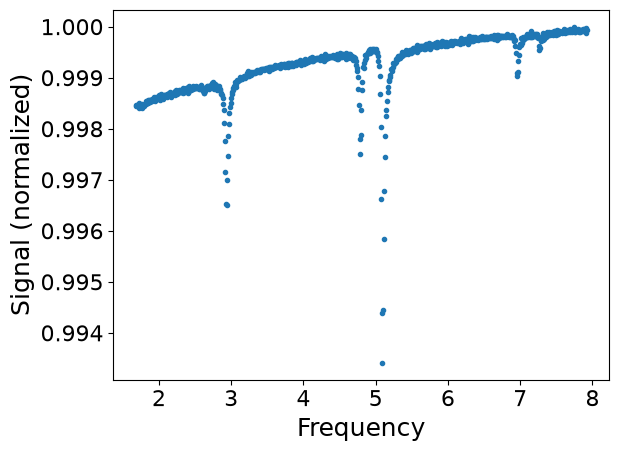

In [27]:
plt.close("all")
#%matplotlib widget
%matplotlib inline
data7 = np.loadtxt("NV_data/data_07.txt")
freqs7, s7 = data7.T
plt.plot(freqs7, s7, ".", label="data")
plt.xlabel("Frequency")
plt.ylabel("Signal (normalized)")

One can then similarly manipulate the nuclear spin. `data_08.txt` is experimental data from a Rabi oscillation measurement, where we excite the sample with a radio wave set to 509 kHz. Note that the time is expressed in ms. 

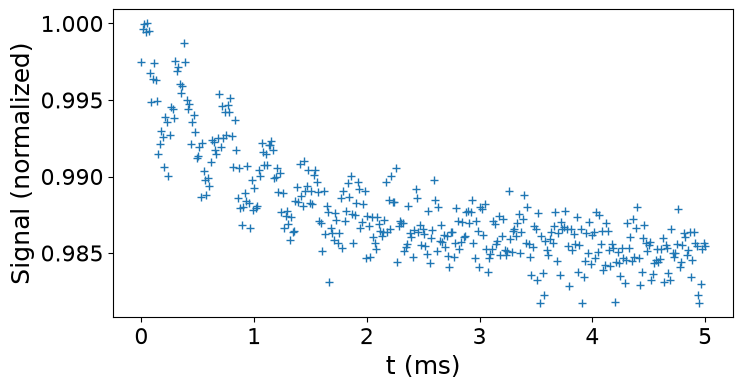

In [29]:
data8 = np.loadtxt("NV_data/data_08.txt")
t8, s8 = data8[:,0], data8[:,1] # time in ns, signal normalized to its maximum value

plt.close('all')
%matplotlib inline
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.plot(t8, s8, "+")
ax.set_xlabel("t (ms)")
ax.set_ylabel("Signal (normalized)")
plt.show()